# Plot Pitch Recordings

In [1]:
%cd ..

D:\Projects\GitHub\introduction-to-sensor-fusion\software


In [2]:
import math

import matplotlib.pyplot as plt
import numpy as np

from utils.loader import load
from utils.orientation import pitch_from_quat
from utils.plotter import plot_imu, plot_pitch

## Helper Functions

Demonstrate our pitch calculation algorithms. Note that we are using the slower for loops (instead of the faster Numpy matrix math), as they are closer to what we would implement on a microcontroller.

In [3]:
def pitch_from_acc(acc):
    """
    Naive pitch (degrees) from the raw accelerometer readings (x and z). We do
    not worry about time here, as each accelerometer reading is a snapshot.
    """
    pitches = np.zeros(acc.shape[0], dtype=float)
    for i, row in enumerate(acc):
        ax = row[0]
        az = row[2]
        pitches[i] = math.degrees(math.atan2(-ax, az))
    
    return pitches

In [4]:
def pitch_from_gyro(t, gs):
    """
    Naive pitch (degrees) from the raw gyroscope reading (single axis). 
    Integrate over time to estimate pitch (rectangle rule).
    """
    # Initialize values
    pitches = np.zeros(gs.shape, dtype=float)
    t_last = 0

    # Go through each gyroscope reading (one axis only)
    for i, g in enumerate(gs):
        # We do not know dt or pitch at the first element, so assume the pitch is 0
        if i == 0:
            pitches[i] = 0
            t_last = t[i]
            continue

        # Calculate dt (in seconds)
        dt = t[i] - t_last
        t_last =  t[i]
    
        # Integrate (rectangle rule) the gyro reading to get estimated pitch
        pitches[i] = pitches[i-1] + (math.degrees(g) * dt)

    return pitches

In [5]:
def pitch_from_gyro_ai(t, gyro_rate, pitch0=0.0):
    """Pitch from integrating the gyro, in degrees."""
    rate_deg = np.degrees(np.asarray(gyro_rate, dtype=float))
    dt = np.diff(np.asarray(t, dtype=float))

    # Trapezoid rule: average the rate at each end of the interval.
    steps = (rate_deg[1:] + rate_deg[:-1]) / 2 * dt
    return np.concatenate([[pitch0], pitch0 + np.cumsum(steps)])

## Slow Pitch

In the ideal case, slowly pitching the board back and forth allows the raw accelerometer or integrated gyroscope readings to be used to calculate the pitch. Such pitch calculation should track the reference output of the BNO085.

In [6]:
# Load slow pitch recording
rec = load("../recordings/pitch_slow")
print(rec.summary())

# Get timing data from the recording
t_acc = rec.acc.t
t_gyro = rec.gyro.t

# Create 2D arrays from the acceleration and gyroscope data
acc = rec.acc.xyz("a")
gyro = rec.gyro.xyz("g")

# View first few rows
print()
print("Accelerometer timestamps (sec):")
print(t_acc.shape)
print(t_acc[0:3])
print()
print("Acceleration (m/s^2):")
print(acc.shape)
print(acc[0:3,:])
print()
print("Gyroscope timestamps (sec):")
print(t_gyro.shape)
print(t_gyro[0:3])
print()
print("Rotational velocity (rad/s):")
print(gyro.shape)
print(gyro[0:3,:])

pitch_slow  (BNO_GRV, 30.2 s)
  acc     3522 samples   117.3 Hz
  gyro    2994 samples    99.8 Hz
  mag     1909 samples    63.7 Hz
  ref     2994 samples    99.8 Hz

Accelerometer timestamps (sec):
(3522,)
[0.200862 0.212234 0.222499]

Acceleration (m/s^2):
(3522, 3)
[[ 0.      -0.72656 10.26562]
 [ 0.07812 -0.80469  9.96094]
 [ 0.11328 -0.80469  9.65234]]

Gyroscope timestamps (sec):
(2994,)
[0.208226 0.218646 0.227886]

Rotational velocity (rad/s):
(2994, 3)
[[ 0.003906 -0.060547  0.      ]
 [ 0.019531 -0.072266 -0.005859]
 [ 0.025391 -0.044922 -0.013672]]


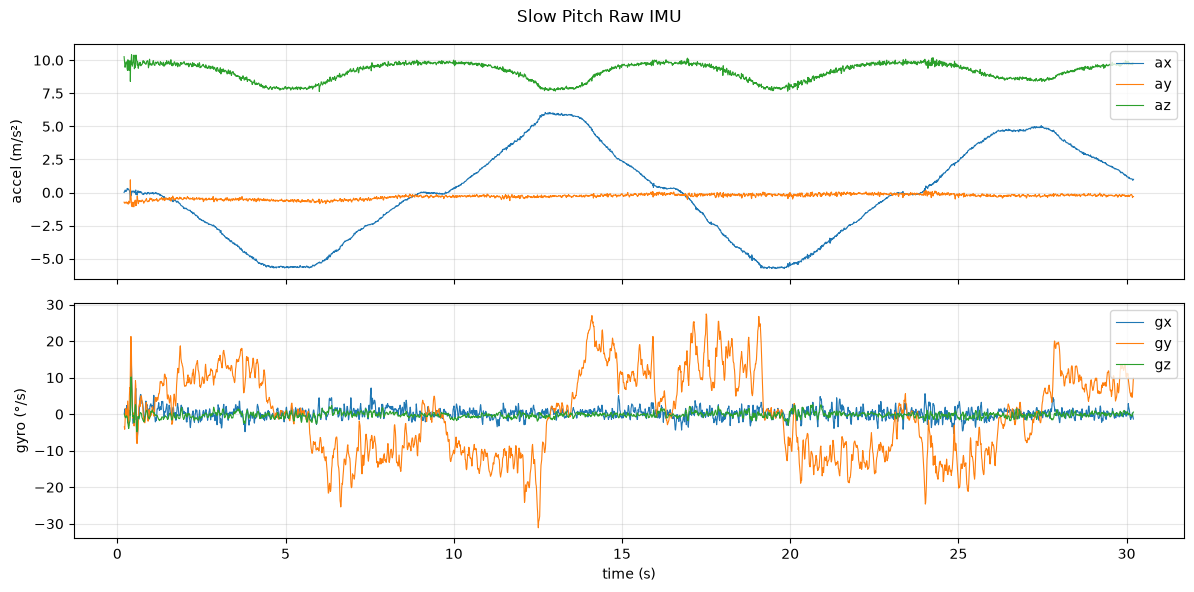

In [7]:
# Plot raw IMU data
_ = plot_imu(rec, streams=("acc","gyro",), title="Slow Pitch Raw IMU")

In [13]:
# Create a 2D array from the reference (quaternion) data
t_quat = rec.ref.t
quat = rec.ref.quat()

# View first few rows of quaternion data
print("Quaternion timestamps (sec):")
print(t_quat.shape)
print(t_quat[0:3])
print()
print("Quaternions:")
print(quat.shape)
print(quat[0:3,:])

Quaternion timestamps (sec):
(2994,)
[0.209781 0.220146 0.229332]

Quaternions:
(2994, 4)
[[ 0.999329 -0.03656  -0.004272 -0.001099]
 [ 0.999329 -0.03656  -0.004578 -0.001099]
 [ 0.999329 -0.036438 -0.004883 -0.001099]]


(<Figure size 1200x500 with 1 Axes>,
 <Axes: xlabel='time (s)', ylabel='pitch (°)'>)

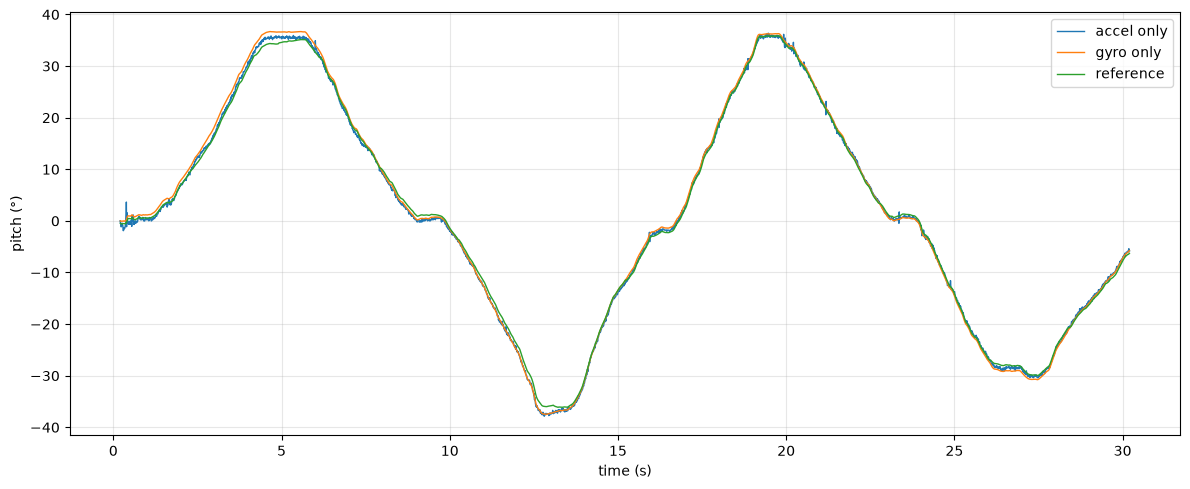

In [14]:
# Get estimated pitches from accelerometer, gyroscope, and reference data
pitch_acc = pitch_from_acc(acc)
pitch_gyro = pitch_from_gyro(t_gyro, gyro[:,1])
pitch_quat = pitch_from_quat(quat)

plot_pitch([
    (t_acc, pitch_acc, "accel only"),
    (t_gyro, pitch_gyro, "gyro only"),
    (t_quat, pitch_quat, "reference"),
])

## 